In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.special import expit as sigmoid
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge, LinearRegression

In [2]:
from utils import DataHandler
from ESN import ESNetwork, ClassicalRC
from reservoirs import CPRC, GBPermanents
from circuits import CPCircuit

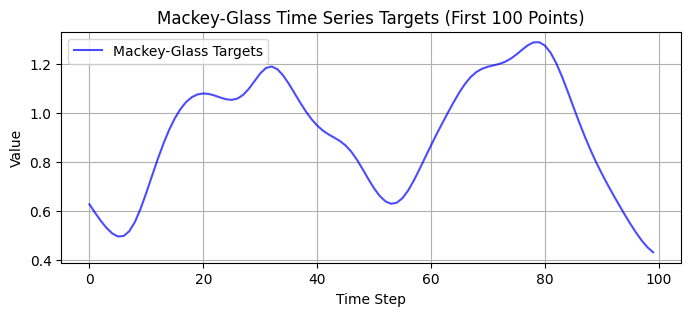

In [3]:
window_size = 20
n_samples = 10000
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = 17, window_size=window_size,prediction_horizon=20, plot=True)

In [4]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_)
X_test = scaler.transform(X_test_) 

In [6]:
itr = 5
a= -1.4746251231135765
b = 1.47
vals = np.linspace(a,b,itr)
dim = len(X_train[0])

In [7]:
CP_params = [vals[2], np.pi/7, -np.pi/3, 7*np.pi/7,np.pi/9, -np.pi/7]
cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel = True) #simulation
esn = ESNetwork(
    reservoir=cprc, 
    dim=dim, 
    regularization=1e-6, 
    alpha=0.8, 
    show_progress=True, 
    approach='feedback', # 'feedback', or 'time-multiplexing'
    model_type='ridge',  # Options: 'ridge', 'lasso', 'linear', 'svr', 'svc'
    limit = 0.6,
    cpk=True)
esn.fit(X_train, y_train)
predictions = esn.predict(X_test)
rmse = mean_squared_error(y_test, predictions)

Prediction Progress: 100%|██████████| 2461/2461 [04:19<00:00,  9.48 sample/s]


In [8]:
rmse

9.970964002980061e-07

In [53]:
rmse

np.float64(8.133873358740709e-07)

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    # ── Font ──────────────────────────────────────────────────
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          12,          # base size for tick labels
    "axes.titlesize":     14,          # subplot title
    "axes.labelsize":     13,          # x/y axis labels
    "legend.fontsize":    11,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,

    # ── Line thickness ────────────────────────────────────────
    "lines.linewidth":    2.5,         # matches the chart line width
    "lines.markersize":   8,           # matches marker size

    # ── Axes ──────────────────────────────────────────────────
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,       # clean look — no top/right border
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,

    # ── Ticks ─────────────────────────────────────────────────
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
    "xtick.major.size":   5,
    "ytick.major.size":   5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",

    # ── Figure / output ───────────────────────────────────────
    "figure.dpi":         150,         # screen preview
    "savefig.dpi":        300,         # print/paper quality
    "savefig.bbox":       "tight",
    "savefig.format":     "pdf",       # vector — best for papers
})

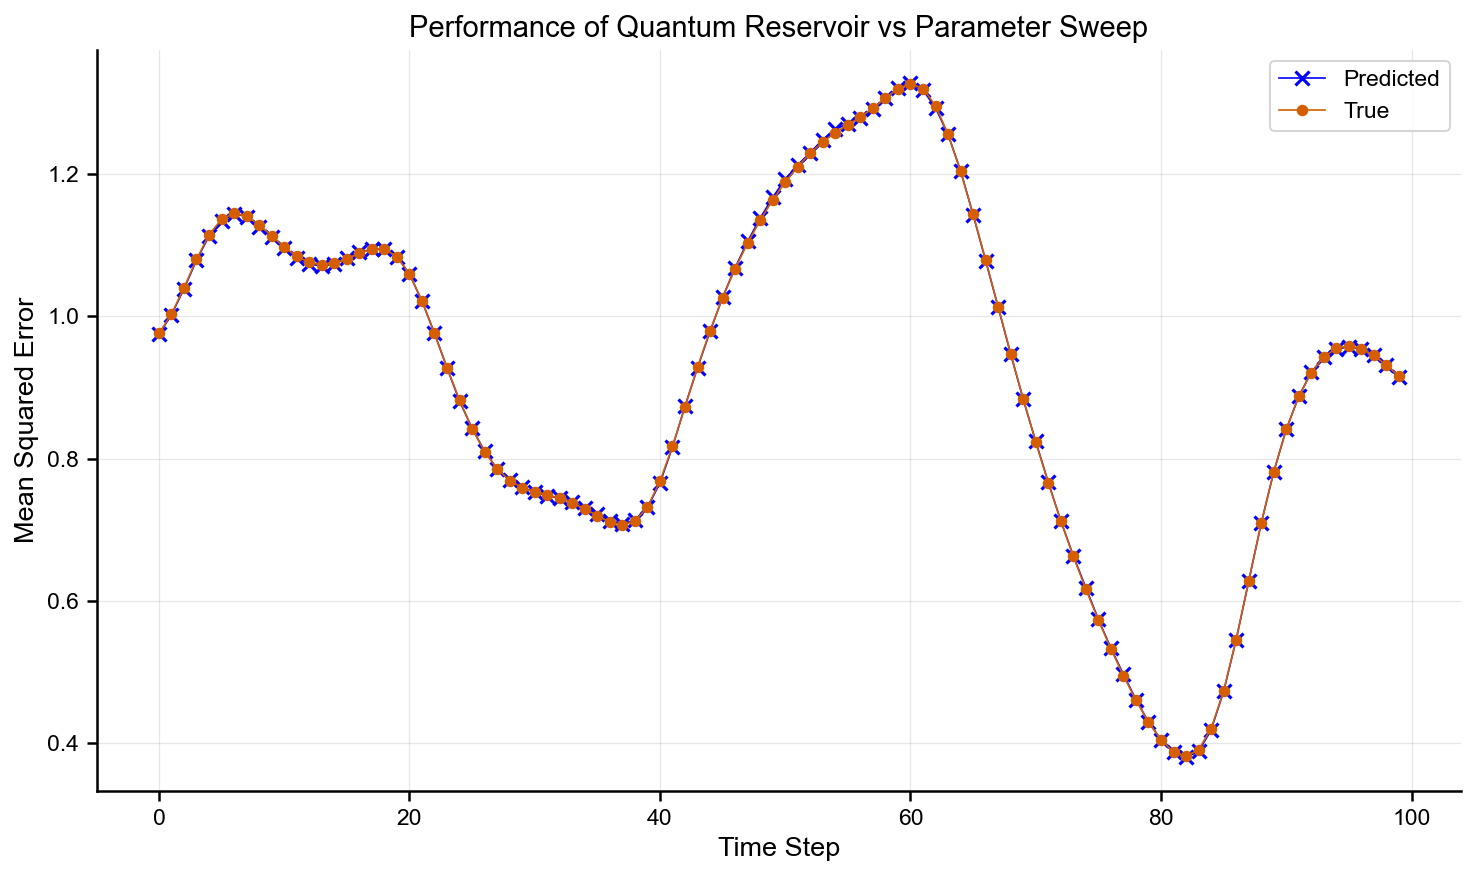

In [23]:
a=0
b=100
param_values = range(b) #[i for i in range(len(predictions))]
plt.figure(figsize=(10, 6))
plt.plot(param_values, predictions[a:b], marker='x', markersize=7, markeredgewidth=1.5, linewidth=0.8, color="blue", linestyle='-', label="Predicted")
plt.plot(param_values, y_test[a:b], marker='o', markersize=4, markeredgewidth=1.5, markerfacecolor='#D55E00', linewidth=0.8, color="#D55E00", linestyle='-', label="True")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Error")
plt.title("Performance of Quantum Reservoir vs Parameter Sweep")
plt.legend()
plt.grid(True)
# plt.savefig("figures/performance_tau_17.pdf")
# plt.savefig("figures/performance_tau_17.png", dpi=300)
plt.tight_layout()
plt.show()

/var/folders/z9/yr53qfdx64v33bmfjf0dyzsm0000gn/T/ipykernel_75139/1976267143.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


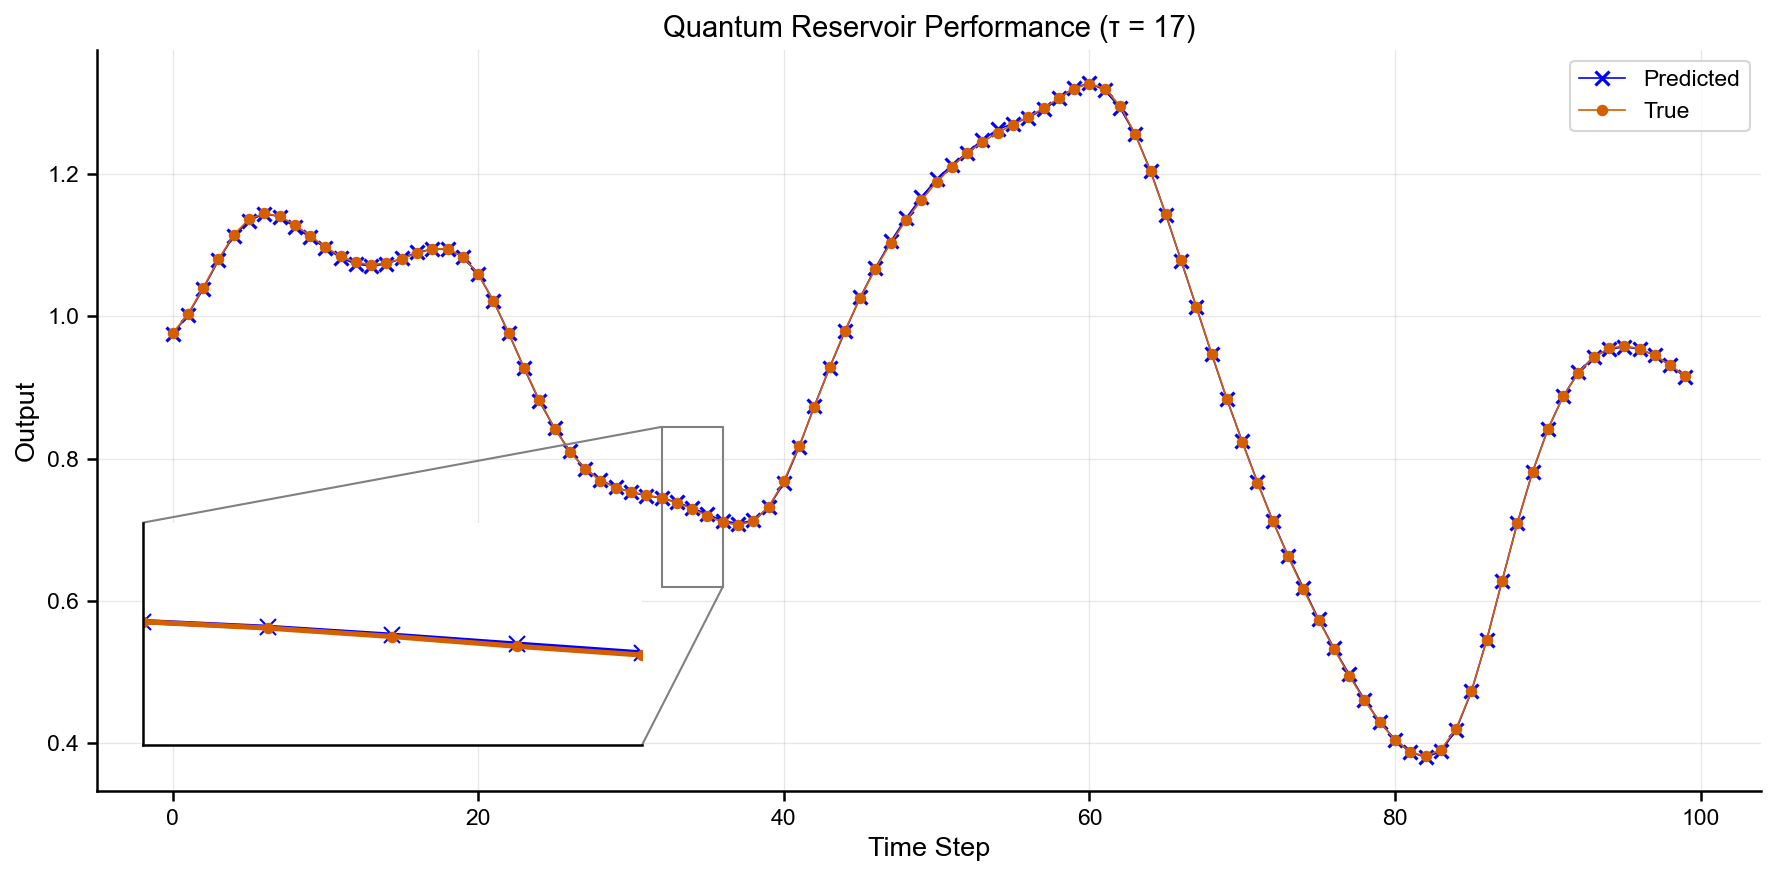

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

a = 0
b = 100
param_values = range(a, b)

# --- Plot full figure
plt.figure(figsize=(12, 6))
main_ax = plt.gca()

# Main plot
main_ax.plot(param_values, predictions[a:b], marker='x', markersize=7, markeredgewidth=1.5, linewidth=0.8, color="blue", linestyle='-', label="Predicted")
main_ax.plot(param_values, y_test[a:b], marker='o', markersize=4, markeredgewidth=1.5, markerfacecolor='#D55E00', linewidth=0.8, color="#D55E00", linestyle='-', label="True")
# main_ax.plot(param_values, predictions[a:b], marker='x', color="blue", linestyle='-', label="Predicted")
# main_ax.plot(param_values, y_test[a:b], marker='o', color="orange", linestyle='-', label="True")
main_ax.set_xlabel("Time Step")
main_ax.set_ylabel("Output")
main_ax.set_title("Quantum Reservoir Performance (τ = 17)")
main_ax.legend()
main_ax.grid(True)

# --- Inset zoom parameters
zoom_start = 32
zoom_end = 36

# Create inset axes (positioned in top right: [x0, y0, width, height])
ax_inset = inset_axes(main_ax, width="30%", height="30%", loc='lower left', borderpad=2)

# Inset plot
ax_inset.plot(param_values, predictions[a:b], marker='x', color="blue", linestyle='-')
ax_inset.plot(param_values, y_test[a:b], marker='o', markersize=4, markeredgewidth=1.5, markerfacecolor='#D55E00', color="#D55E00", linestyle='-')
ax_inset.set_xlim(zoom_start, zoom_end)
ax_inset.set_ylim(
    min(min(predictions[zoom_start:zoom_end]), min(y_test[zoom_start:zoom_end])) - 0.1,
    max(max(predictions[zoom_start:zoom_end]), max(y_test[zoom_start:zoom_end])) + 0.1
)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.grid(True)

# Connect zoom box to inset
mark_inset(main_ax, ax_inset, loc1=2, loc2=4, fc="none", ec="gray", lw=1)

# Save
plt.tight_layout()
plt.savefig("figures/performance_tau_17_zoomed.pdf")
plt.savefig("figures/performance_tau_17_zoomed.png", dpi=300)
plt.show()


/var/folders/z9/yr53qfdx64v33bmfjf0dyzsm0000gn/T/ipykernel_5884/3592233365.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


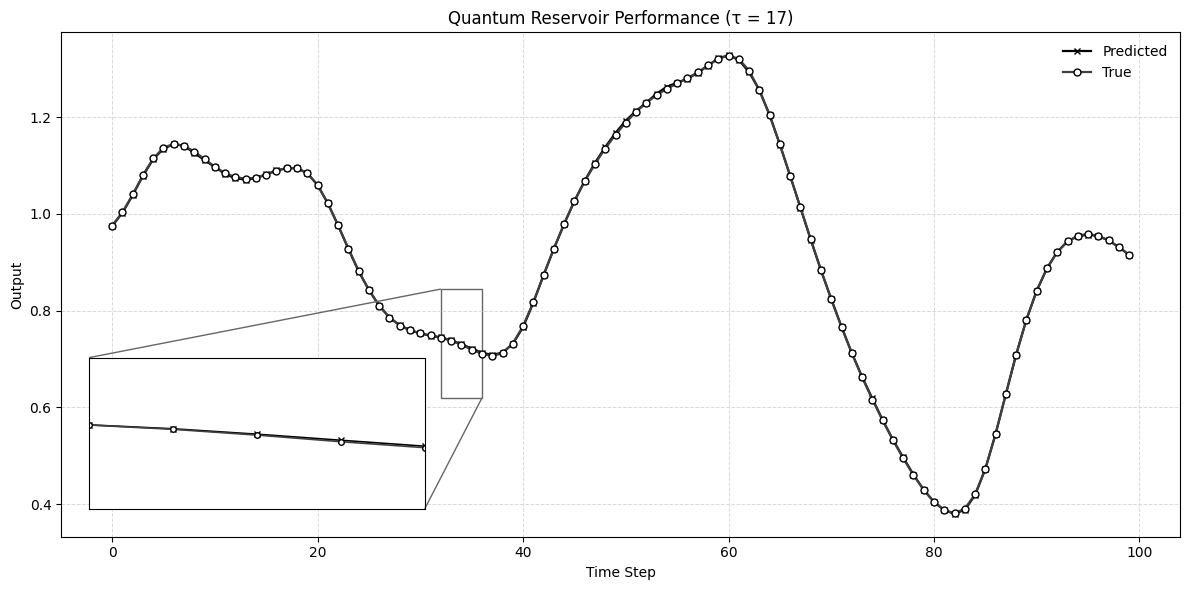

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

a = 0
b = 100
param_values = range(a, b)

plt.figure(figsize=(12, 6))
main_ax = plt.gca()

# --- Main plot (black vs dark gray, hollow vs filled markers for clarity) ---
main_ax.plot(
    param_values, predictions[a:b],
    linestyle='-', linewidth=1.6,
    marker='x', markersize=5,
    color='0.0', label="Predicted"
)
main_ax.plot(
    param_values, y_test[a:b],
    linestyle='-', linewidth=1.6,
    marker='o', markersize=5,
    markerfacecolor='1.0', markeredgecolor='0.0',
    color='0.25', label="True"
)

main_ax.set_xlabel("Time Step", color='0.0')
main_ax.set_ylabel("Output", color='0.0')
main_ax.set_title("Quantum Reservoir Performance (τ = 17)", color='0.0')
main_ax.grid(True, linestyle='--', linewidth=0.7, color='0.85')
main_ax.tick_params(axis='both', colors='0.0')
for spine in main_ax.spines.values():
    spine.set_color('0.0')

leg = main_ax.legend(frameon=False)

# --- Inset zoom parameters ---
zoom_start = 32
zoom_end = 36

# --- Inset axes (monochrome) ---
ax_inset = inset_axes(main_ax, width="30%", height="30%", loc='lower left', borderpad=2)

ax_inset.plot(
    param_values, predictions[a:b],
    linestyle='-', linewidth=1.2,
    marker='x', markersize=4,
    color='0.0'
)
ax_inset.plot(
    param_values, y_test[a:b],
    linestyle='-', linewidth=1.2,
    marker='o', markersize=4,
    markerfacecolor='1.0', markeredgecolor='0.0',
    color='0.25'
)

ax_inset.set_xlim(zoom_start, zoom_end)
ymin = min(min(predictions[zoom_start:zoom_end]), min(y_test[zoom_start:zoom_end])) - 0.1
ymax = max(max(predictions[zoom_start:zoom_end]), max(y_test[zoom_start:zoom_end])) + 0.1
ax_inset.set_ylim(ymin, ymax)

ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.grid(True, linestyle='--', linewidth=0.6, color='0.85')
for spine in ax_inset.spines.values():
    spine.set_color('0.0')

# Connect zoom box to inset (gray connector)
mark_inset(main_ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

# Save
plt.tight_layout()
plt.savefig("figures/bw_performance_tau_17_zoomed_bw.pdf", bbox_inches='tight')
# plt.savefig("figures/performance_tau_17_zoomed_bw.png", dpi=300, bbox_inches='tight')
plt.show()


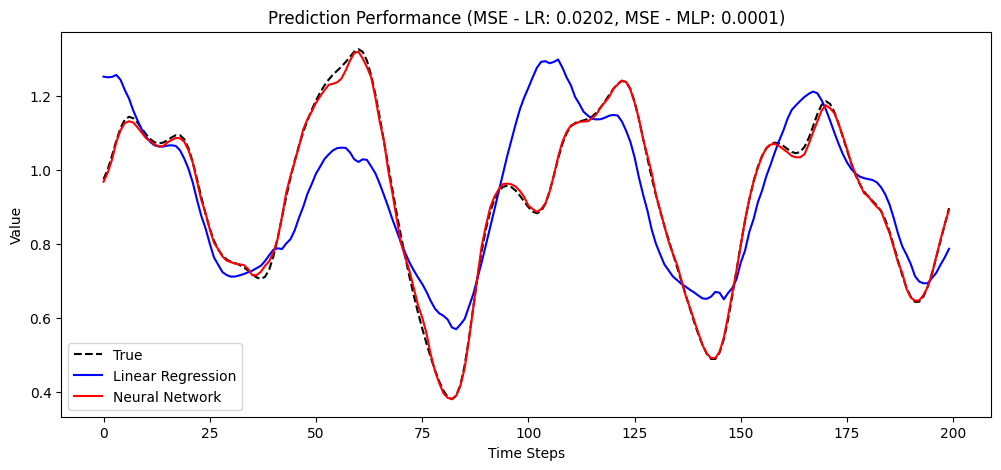

MSE for LR: 0.020171711517532057, MSE for MLP: 8.59571306668173e-05


In [56]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train Neural Network Regression Model
mlp_model = MLPRegressor(hidden_layer_sizes=(500,), activation='relu', max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# Evaluate Performance
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(y_test[:200], label="True", linestyle="dashed", color="black")
plt.plot(y_pred_lr[:200], label="Linear Regression", color="blue")
plt.plot(y_pred_mlp[:200], label="Neural Network", color="red")
plt.legend()
plt.title(f"Prediction Performance (MSE - LR: {mse_lr:.4f}, MSE - MLP: {mse_mlp:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

# Display MSE results
print(f"MSE for LR: {mse_lr}, MSE for MLP: {mse_mlp}")

In [72]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# Define Ridge and Lasso grids
ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_search = GridSearchCV(Ridge(), ridge_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
lasso_search = GridSearchCV(Lasso(max_iter=5000), lasso_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)

# Predict with best estimators
y_pred_ridge = ridge_search.best_estimator_.predict(X_test)
y_pred_lasso = lasso_search.best_estimator_.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)


In [73]:
from sklearn.neural_network import MLPRegressor

mlp_grid = {
    'hidden_layer_sizes': [(100,), (200,), (300,), (500,), (300, 100)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

mlp = MLPRegressor(max_iter=1000, random_state=42)
mlp_search = GridSearchCV(mlp, mlp_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
mlp_search.fit(X_train, y_train)

y_pred_mlp = mlp_search.best_estimator_.predict(X_test)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)

In [75]:
print("Best Ridge alpha:", ridge_search.best_params_)
print("Best Lasso alpha:", lasso_search.best_params_)
print("Best MLP params:", mlp_search.best_params_)

print(f"MSE for Ridge: {mse_ridge:.4f}")
print(f"MSE for Lasso: {mse_lasso:.4f}")
print(f"MSE for MLP: {mse_mlp:.7f}")


Best Ridge alpha: {'alpha': 0.001}
Best Lasso alpha: {'alpha': 0.001}
Best MLP params: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (300, 100), 'learning_rate_init': 0.001}
MSE for Ridge: 0.0202
MSE for Lasso: 0.0205
MSE for MLP: 0.0000415


In [68]:
from joblib import Parallel, delayed, parallel_backend
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_crm(spectral_radius, reservoir_size, sparsity, noise):
    try:
        CRM = ClassicalRC(
            input_size=len(X_train[0]),
            reservoir_size=reservoir_size,
            spectral_radius=spectral_radius,
            sparsity=sparsity,
            noise=noise,
            use_reservoir=True
        )
        CRM.train(np.array(X_train), y_train, model_type="ridge")
        y_pred = CRM.predict(np.array(X_test))
        mse = mean_squared_error(y_test, y_pred)
        print(mse)
        rmse = np.sqrt(mse)
        return spectral_radius, reservoir_size, sparsity, noise, mse
    except Exception as e:
        return spectral_radius, reservoir_size, sparsity, noise, f"Error: {e}"


In [69]:
from itertools import product

spectral_radii = [0.1, 0.3, 0.5, 0.7, 0.9]
reservoir_sizes = [50, 100, 150, 200]
sparsities = [0.05, 0.1, 0.2]
noises = [0.0, 1e-4, 1e-3]

param_grid = list(product(spectral_radii, reservoir_sizes, sparsities, noises))


In [70]:
with parallel_backend("loky", n_jobs=-1):
    results = Parallel()(
        delayed(evaluate_crm)(sr, rs, sp, ns)
        for sr, rs, sp, ns in param_grid
    )


In [71]:
# Convert to DataFrame and remove failed runs
import pandas as pd

df_results = pd.DataFrame([
    (sr, rs, sp, ns, rmse)
    for sr, rs, sp, ns, rmse in results
    if isinstance(rmse, (float, int)) and not np.isnan(rmse)
], columns=["spectral_radius", "reservoir_size", "sparsity", "noise", "rmse"])

# Sort by performance
df_sorted = df_results.sort_values(by="rmse")
print(df_sorted.head())

# Best config
best_params = df_sorted.iloc[0]
print("\nBest parameters:\n", best_params)


     spectral_radius  reservoir_size  sparsity   noise      rmse
174              0.9             200       0.1  0.0000  0.000345
175              0.9             200       0.1  0.0001  0.000345
176              0.9             200       0.1  0.0010  0.000349
138              0.7             200       0.1  0.0000  0.000396
139              0.7             200       0.1  0.0001  0.000396

Best parameters:
 spectral_radius      0.900000
reservoir_size     200.000000
sparsity             0.100000
noise                0.000000
rmse                 0.000345
Name: 174, dtype: float64


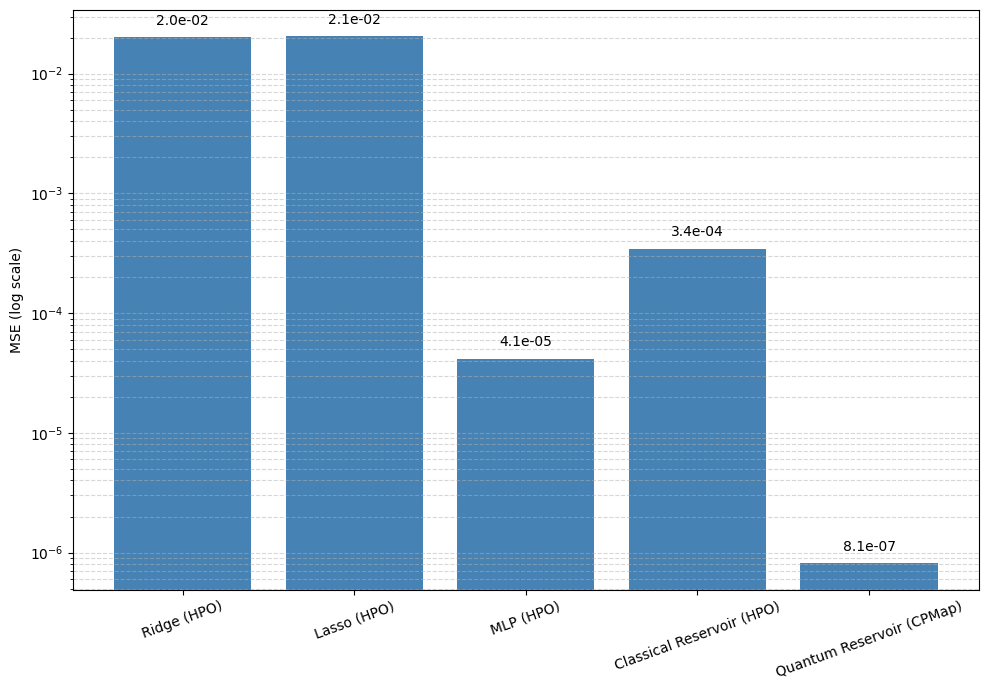

In [97]:
# Example MSEs (replace these with your actual results)
model_names = [
    "Ridge (HPO)",
    "Lasso (HPO)",
    "MLP (HPO)",
    "Classical Reservoir (HPO)",
    "Quantum Reservoir (CPMap)"
]

mses = [0.0202,0.0205,0.0000415,0.000345,8.133873358740709e-07]
# log_mses = np.log10(mses)

plt.figure(figsize=(10, 7))
bars = plt.bar(x_vals, mses, color='steelblue')
plt.yscale('log')

# Add scientific notation labels on top
for bar, mse in zip(bars, mses):
    plt.text(bar.get_x() + bar.get_width()/2, mse * 1.2, f"{mse:.1e}",
             ha='center', va='bottom', fontsize=10)

plt.xticks(x_vals, model_names, rotation=20, ha='center')
plt.ylabel("MSE (log scale)")
# plt.title("Model Comparison (Bar Chart, Log MSE)")
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/model_comparison_bar_log.pdf")
plt.show()


# # Save in high-res for LaTeX
# plt.savefig("figures/model_comparison_mse.pdf")
# plt.savefig("figures/model_comparison_mse.png", dpi=300)

# plt.show()


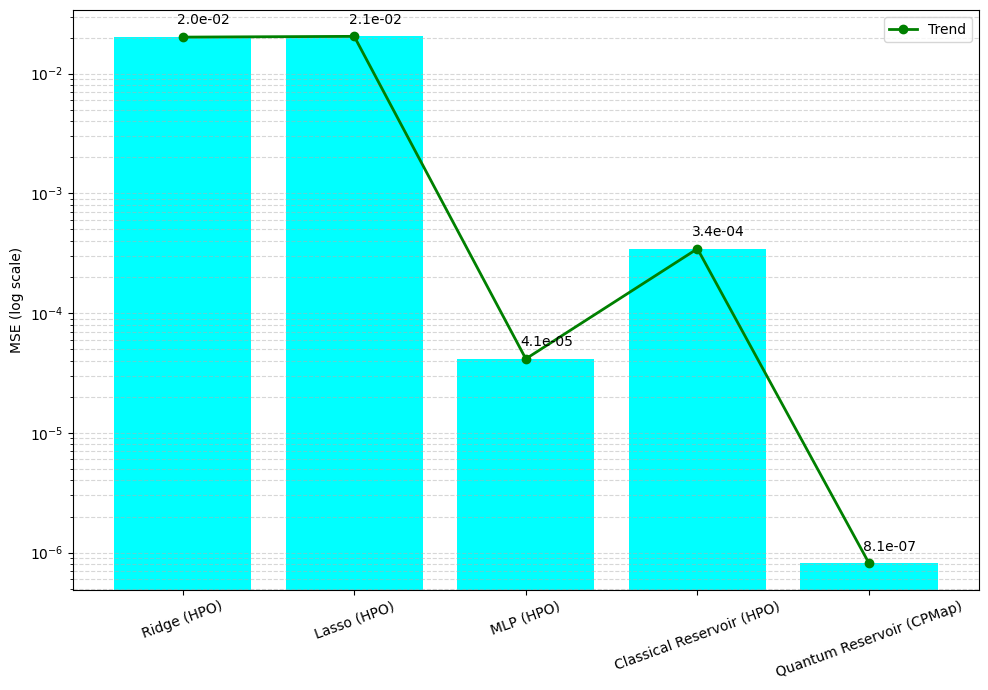

In [129]:
x_vals = np.arange(len(model_names))

plt.figure(figsize=(10, 7))
bars = plt.bar(x_vals, mses, color='cyan')
plt.yscale('log')

# Add line plot over bar tops
bar_centers = [bar.get_x() + bar.get_width() / 2 for bar in bars]
bar_tops = [bar.get_height() for bar in bars]
plt.plot(bar_centers, bar_tops, color='green', marker='o', linewidth=2, label="Trend")

# Use annotate for scientific notation
ax = plt.gca()
for x, mse in zip(bar_centers, bar_tops):
    ax.annotate(
        f"{mse:.1e}",
        xy=(x, mse),
        xytext=(15, 7),  # 8 points above the bar
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        color="black"
    )

# Axis formatting
plt.xticks(x_vals, model_names, rotation=20, ha='center')
plt.ylabel("MSE (log scale)")
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

# Save for paper
plt.savefig("figures/model_comparison_bar_log.pdf")
# plt.savefig("figures/model_comparison_bar_log.png", dpi=300)
plt.show()
